<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day10_practice3_%ED%95%9C%EA%B3%84%EC%99%80_%EB%8F%99%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 사전학습 모델의 한계 - 커스텀 학습의 동기

In [1]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.8 MB/s eta 0:00:00


In [2]:
!apt-get -qq install -y fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [4]:
from ultralytics import YOLO
from PIL import Image, ImageEnhance, ImageFilter
import urllib.request, os, time
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [5]:
BUS_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
if not os.path.exists("bus.jpg"):
  urllib.request.urlretrieve(BUS_URL, "bus.jpg")
  print("bus.jpg 다운로드 완료 (재실행 시 재사용)")

bus.jpg 다운로드 완료 (재실행 시 재사용)


In [6]:
model = YOLO("yolo11n.pt")

In [7]:
# 셀 1. COCO에 도로 위험은 없다
coco_classes = list(model.names.values()) # model.names = {번호: 이름}
print(f"COCO 클래스 {len(coco_classes)}종 중에서 찾아보면:")
for word in ["pothole", "crack", "manhole", "road"]:
  found = [c for c in coco_classes if word in c.lower()]
  print(f" '{word}' 포함 클래스: {found if found else '없음'}")
print("\n80종 전체:", coco_classes)

COCO 클래스 80종 중에서 찾아보면:
 'pothole' 포함 클래스: 없음
 'crack' 포함 클래스: 없음
 'manhole' 포함 클래스: 없음
 'road' 포함 클래스: 없음

80종 전체: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


[열화 실험] conf=0.25 기준:
원본           → 5개 [('bus', 0.94), ('person', 0.89), ('person', 0.88), ('person', 0.86), ('person', 0.62)]
어둡게(x0.3)    → 6개 [('bus', 0.95), ('person', 0.88), ('person', 0.86), ('person', 0.86), ('skateboard', 0.52), ('person', 0.51)]
축소(160px)    → 4개 [('person', 0.85), ('person', 0.81), ('bus', 0.76), ('person', 0.65)]
블러(반경5)      → 6개 [('person', 0.89), ('person', 0.85), ('person', 0.81), ('bus', 0.77), ('person', 0.49), ('person', 0.29)]


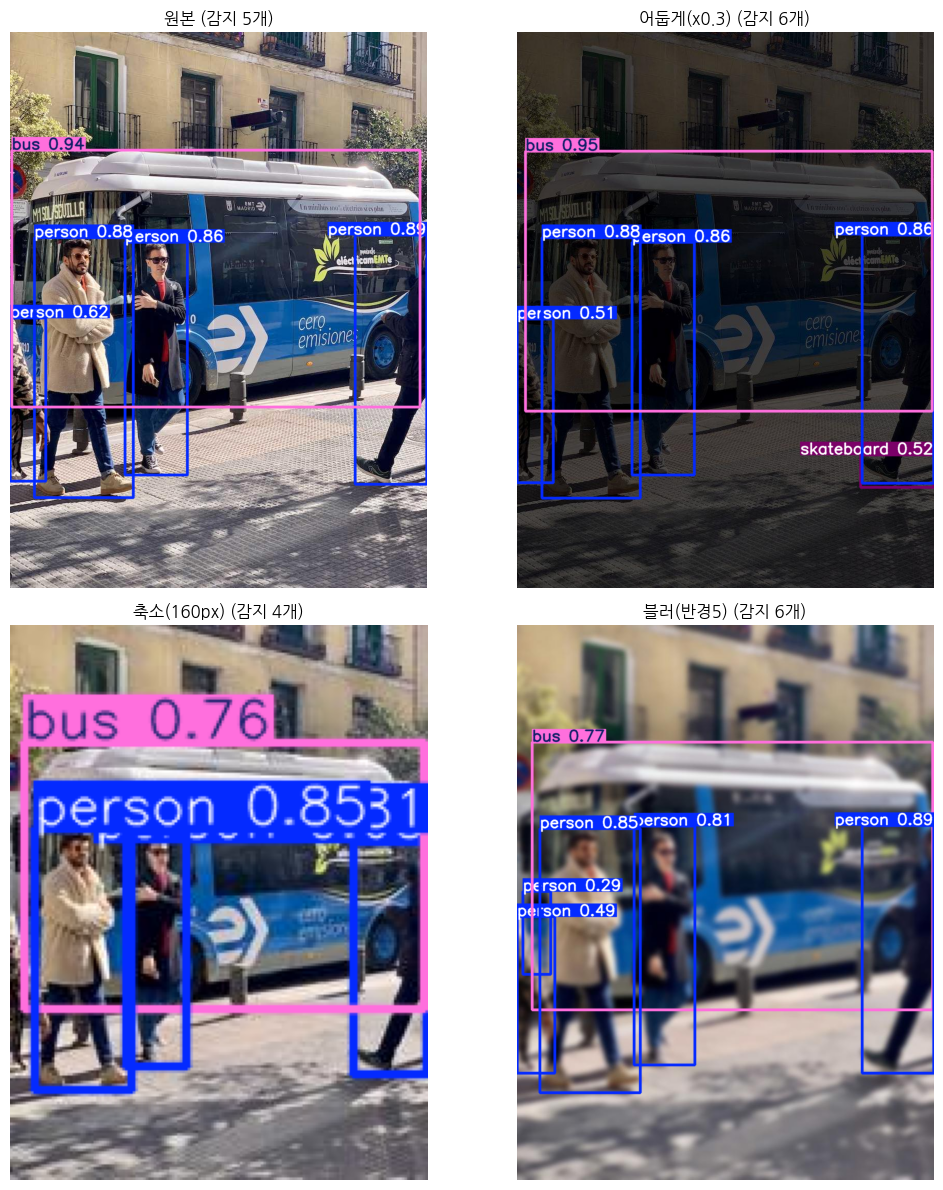

In [8]:
# 셀 2. 강건성 실험 - 현실의 사진은 깨끗하지 않다
# 신고 앱의 현실: 밤길, 흔들린 손, 저사양 폰
# 같은 사진을 3가지로 열화시켜(사진의 화질이나 상태를 나쁘게 만든다) 감지가 어떻게 무너지는지 실측

src = Image.open("bus.jpg")
variants = {
    "원본": src,
    "어둡게(x0.3)": ImageEnhance.Brightness(src).enhance(0.3), # 밝기 조절. 0.3=원본의 30% (어둡게)
    "축소(160px)": src.resize((160, int(160 * src.height / src.width))), # 저해상. resize((너비, 높이)), 비율 유지 계산 후 높이 지정
    "블러(반경5)": src.filter(ImageFilter.GaussianBlur(5)), # 손떨림 모사. filter(GaussianBlur(반경)), 반경 클수록 더 흐림
}
print("[열화 실험] conf=0.25 기준:")

fig, axes = plt.subplots(2, 2, figsize=(11, 12))
axes = axes.ravel() # 1차원(4개)으로 펴서 순서대로
for vi, (name, im) in enumerate(variants.items()):
  path = f"variant_{vi}.jpg"
  im.save(path) # 변형 이미지를 파일로 저장
  r = model(path, verbose=False)[0]
  dets = [(r.names[int(b.cls)], round(float(b.conf), 2)) for b in r.boxes]
  print(f"{name:12s} → {len(dets)}개 {dets}")

  axes[vi].imshow(r.plot()[:, :, ::-1])
  axes[vi].set_title(f"{name} (감지 {len(dets)}개)")
  axes[vi].axis("off")
  os.remove(path)

plt.tight_layout()
plt.show()